In [1]:
import torch
import os
import math
from typing import Dict, Any

def window_permutation(H: int, W: int, Wh: int, Ww: int, hierarchical: bool = False) -> torch.Tensor:
    """
    Return a permutation idx such that x.view(H*W)[idx] is reordered
    window-by-window (raster scan over windows, raster scan inside each window).
    If hierarchical=True, first permute to window-first order with Wh x Ww windows,
    then within each window, permute to subwindow-first order with (Wh/4) x (Ww/4) subwindows.
    """
    if not (H % Wh == 0 and W % Ww == 0):
        raise ValueError(f"H({H}), W({W}) must be divisible by Wh({Wh}), Ww({Ww})")
    
    idx = torch.arange(H * W).reshape(H, W)
    
    if not hierarchical:
        # Non-hierarchical permutation
        patches = idx.unfold(0, Wh, Wh).unfold(1, Ww, Ww)  # (nWh, nWw, Wh, Ww)
        perm = patches.contiguous().view(-1)               # (H*W,)
        return perm
    
    # Hierarchical permutation
    if not (Wh % 4 == 0 and Ww % 4 == 0):
        raise ValueError(f"For hierarchical=True, Wh({Wh}) and Ww({Ww}) must be divisible by 4")
    
    # First level: permute to window-first order with Wh x Ww windows
    patches = idx.unfold(0, Wh, Wh).unfold(1, Ww, Ww)  # (nWh, nWw, Wh, Ww)
    
    # Second level: within each window, permute to subwindow-first order
    sub_Wh, sub_Ww = Wh // 4, Ww // 4
    # Shape: (nWh, nWw, 4, 4, sub_Wh, sub_Ww)
    hierarchical_patches = patches.unfold(2, sub_Wh, sub_Wh).unfold(3, sub_Ww, sub_Ww)
    
    # Reshape to get subwindow-first order. The memory layout from unfold is already
    # correct for a raster-scan-style flattening, so no permute is needed.
    perm = hierarchical_patches.contiguous().view(-1)   # (H*W,)
    return perm

def hilbert_window_permutation(H: int, W: int, Wh: int, Ww: int) -> torch.Tensor:
    """
    Return a permutation idx that orders tokens using Hilbert curves within windows.
    First, tokens are grouped into windows of size Wh x Ww.
    Within each window, tokens are ordered following a Hilbert curve pattern.
    Windows themselves are ordered in raster scan order.

    Args:
        H: Height of the 2D grid (tokens laid out row-major)
        W: Width of the 2D grid
        Wh: Window height
        Ww: Window width

    Returns:
        torch.LongTensor of shape (H*W,) with global indices in Hilbert-windowed order.
    """
    if Wh <= 0 or Ww <= 0:
        raise ValueError(f"Wh and Ww must be positive, got Wh={Wh}, Ww={Ww}")
    if H <= 0 or W <= 0:
        raise ValueError(f"H and W must be positive, got H={H}, W={W}")
    if (H % Wh) != 0 or (W % Ww) != 0:
        raise ValueError(f"H({H}), W({W}) must be divisible by Wh({Wh}), Ww({Ww})")

    # Next power of two that accommodates the window (works for rectangular windows too)
    n_side = 1 << math.ceil(math.log2(max(Wh, Ww)))

    # --- Hilbert helpers (iterative, reliable) ---
    def _rot(s: int, x: int, y: int, rx: int, ry: int):
        # Rotate/flip a quadrant appropriately
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            # swap x and y
            x, y = y, x
        return x, y

    def _xy2d(n: int, x: int, y: int) -> int:
        # Map (x,y) in [0,n)×[0,n) to Hilbert distance d
        d = 0
        s = n // 2
        while s > 0:
            rx = 1 if (x & s) else 0
            ry = 1 if (y & s) else 0
            d += s * s * ((3 * rx) ^ ry)
            x, y = _rot(s, x, y, rx, ry)
            s //= 2
        return d

    # Precompute the Hilbert order (as (hilbert_d, h, w)) for a single Wh×Ww window,
    # embedding coordinates into n_side×n_side.
    per_window = []
    per_window.reserve if hasattr(per_window, "reserve") else None  # no-op in Python, keeps intent clear
    for h in range(Wh):
        for w in range(Ww):
            d = _xy2d(n_side, h, w)
            per_window.append((d, h, w))
    per_window.sort(key=lambda t: t[0])  # sort by Hilbert distance

    # Build global permutation by raster-scanning windows and applying within-window Hilbert order
    idx_grid = torch.arange(H * W, dtype=torch.long).reshape(H, W)
    num_windows_h = H // Wh
    num_windows_w = W // Ww

    perm = torch.empty(H * W, dtype=torch.long)
    out_ptr = 0
    for win_i in range(num_windows_h):
        h0 = win_i * Wh
        h1 = h0 + Wh
        for win_j in range(num_windows_w):
            w0 = win_j * Ww
            w1 = w0 + Ww
            window_indices = idx_grid[h0:h1, w0:w1]
            for _, h, w in per_window:
                perm[out_ptr] = window_indices[h, w]
                out_ptr += 1

    return perm

def _create_distance_mask_chunked(
    indices_h: torch.Tensor,
    indices_w: torch.Tensor,
    radius_h: int,
    radius_w: int,
    chunk_size: int = 4096,
) -> torch.Tensor:
    """
    Creates a boolean attention mask based on token distance in a memory-efficient way
    by processing the mask in horizontal chunks to avoid large intermediate tensors.
    """
    seq_len = indices_h.numel()
    mask = torch.empty(seq_len, seq_len, dtype=torch.bool, device=indices_h.device)
    
    indices_h_row = indices_h.unsqueeze(0)
    indices_w_row = indices_w.unsqueeze(0)

    for i in range(0, seq_len, chunk_size):
        end = min(i + chunk_size, seq_len)
        h_chunk_col = indices_h[i:end].unsqueeze(1)
        w_chunk_col = indices_w[i:end].unsqueeze(1)
        
        dist_mask_chunk = (torch.abs(h_chunk_col - indices_h_row) <= radius_h) & \
                          (torch.abs(w_chunk_col - indices_w_row) <= radius_w)
        mask[i:end, :] = dist_mask_chunk
        
    return mask

def _create_id_mask_chunked(
    query_ids: torch.Tensor,
    key_ids: torch.Tensor = None,
    chunk_size: int = 1024
) -> torch.Tensor:
    """
    Creates a boolean attention mask by matching IDs between query and key tokens.
    Processes the mask in chunks to conserve memory.
    """
    if key_ids is None:
        key_ids = query_ids

    seq_len_q = query_ids.numel()
    seq_len_k = key_ids.numel()
    mask = torch.empty(seq_len_q, seq_len_k, dtype=torch.bool, device=query_ids.device)

    key_ids_row = key_ids.unsqueeze(0)
    for i in range(0, seq_len_q, chunk_size):
        end = min(i + chunk_size, seq_len_q)
        query_chunk_col = query_ids[i:end].unsqueeze(1)
        mask[i:end, :] = (query_chunk_col == key_ids_row)
        
    return mask

def _build_mask(
    model_config: Dict[str, Any] = {},
    device: torch.device = torch.device("cuda:7"),
    dtype: torch.dtype = torch.bfloat16,
    block_idx: int = 0,
    image_size: tuple[int, int] = (2048, 2048),
    joint_denoise_H: int = 512,
    joint_denoise_W: int = 512,
) -> torch.Tensor:
    """Build unified KV representation and attention mask using memory-optimized, chunked operations."""
    
    text_seq_len = 512
    image_size = image_size
    patch_size = 16
    window_size = 256, 256
    
    H_p = image_size[0] // patch_size
    W_p = image_size[1] // patch_size
    window_patches_H = window_size[0] // patch_size
    window_patches_W = window_size[1] // patch_size
    joint_denoise_H = joint_denoise_H // patch_size
    joint_denoise_W = joint_denoise_W // patch_size
    
    shift_size_H = 0
    shift_size_W = 0
    if not model_config.get("use_sliding_window", True):
        if block_idx % 2 == 1: # Shift for odd layers
            shift_size_H = window_patches_H // 2
            shift_size_W = window_patches_W // 2
    
    h_windows = math.ceil(H_p / window_patches_H)
    w_windows = math.ceil(W_p / window_patches_W)
    
    hi_res_len = H_p * W_p
    low_res_len = joint_denoise_H * joint_denoise_W 
    total_q_len = text_seq_len + hi_res_len + low_res_len
    
    attention_mask = torch.zeros(total_q_len, total_q_len, dtype=torch.bool, device=device)
    
    # =================== Text Attention Patterns ===================
    if model_config.get("text_attend_scale", "hr_and_T") == "all":
        attention_mask[:text_seq_len, :] = True
    else:
        attention_mask[:text_seq_len, :-low_res_len] = True
    
    attention_mask[:-low_res_len, :text_seq_len] = True
    
    # =================== Hi-Res Window Attention ===================
    h_indices = torch.arange(hi_res_len, device=device) // W_p
    w_indices = torch.arange(hi_res_len, device=device) % W_p
    
    hi_res_start = text_seq_len
    hi_res_end = text_seq_len + hi_res_len
    
    if model_config.get("use_sliding_window", True):
        # --- Sliding Window Attention (Memory Optimized) ---
        window_radius_H = window_patches_H // 2
        window_radius_W = window_patches_W // 2
        # print(h_indices)
        # print(h_indices.shape)
        # print(window_radius_H)
        sliding_window_mask = _create_distance_mask_chunked(
            h_indices, w_indices, window_radius_H, window_radius_W
        )
        
        if model_config.get("permute_window_first", True):
            perm = window_permutation(H_p, W_p, window_patches_H, window_patches_W).to(device)
            sliding_window_mask = sliding_window_mask.index_select(0, perm).index_select(1, perm)
        
        attention_mask[hi_res_start:hi_res_end, hi_res_start:hi_res_end] = sliding_window_mask
        
    else:
        # --- Shifted Window Attention (Memory Optimized) ---
        shifted_h = h_indices
        shifted_w = w_indices
        if shift_size_H > 0 or shift_size_W > 0:
            shifted_h = (h_indices + shift_size_H) % H_p
            shifted_w = (w_indices + shift_size_W) % W_p
        
        window_h_ids = shifted_h // window_patches_H
        window_w_ids = shifted_w // window_patches_W
        window_ids = window_h_ids * w_windows + window_w_ids
        
        same_window_mask = _create_id_mask_chunked(window_ids)
        
        if model_config.get("use_overlap_window", False):
            window_h_ids_half = window_h_ids // 2
            window_w_ids_half = window_w_ids // 2
            window_ids_half = window_h_ids_half * w_windows + window_w_ids_half
            same_window_mask_half = _create_id_mask_chunked(window_ids_half)
            torch.logical_or(same_window_mask, same_window_mask_half, out=same_window_mask)

        attention_mask[hi_res_start:hi_res_end, hi_res_start:hi_res_end] = same_window_mask
    
    # =================== Hi-Res to Low-Res Attention ===================
    if model_config.get("hi_res_attend_scale", "all") == "all":
        scale_H = max(H_p // joint_denoise_H, 1)
        scale_W = max(W_p // joint_denoise_W, 1)
        win_H_lr = max(window_patches_H // scale_H, 1)
        win_W_lr = max(window_patches_W // scale_W, 1)

        h_lr_idx = torch.arange(low_res_len, device=device) // joint_denoise_W
        w_lr_idx = torch.arange(low_res_len, device=device) %  joint_denoise_W
        lr_win_h = h_lr_idx // win_H_lr
        lr_win_w = w_lr_idx // win_W_lr
        lr_w_windows = math.ceil(joint_denoise_W / win_W_lr)
        lr_window_ids = lr_win_h * lr_w_windows + lr_win_w

        target_lh = (h_indices // scale_H) // win_H_lr
        target_lw = (w_indices // scale_W) // win_W_lr
        target_lr_window_ids = target_lh * lr_w_windows + target_lw
        
        # This mask is [H, L], which is not N^2 and typically fits in memory.
        # If it ever becomes a bottleneck, it can also be chunked.
        # hr_to_lr = (target_lr_window_ids.unsqueeze(1) == lr_window_ids.unsqueeze(0))
        hr_to_lr = torch.abs(target_lr_window_ids.unsqueeze(1) - lr_window_ids.unsqueeze(0)) <= 1
        attention_mask[hi_res_start:hi_res_end, -low_res_len:] = hr_to_lr

        if model_config.get("permute_window_first", True):
                perm_hr = window_permutation(H_p, W_p, window_patches_H, window_patches_W).to(device)
                perm_lr = window_permutation(joint_denoise_H, joint_denoise_W, 4, 4).to(device)
                attention_mask[hi_res_start:hi_res_end, -low_res_len:] = (
                    attention_mask[hi_res_start:hi_res_end, -low_res_len:]
                    .index_select(0, perm_hr).index_select(1, perm_lr)
                )
        # lr_block = 256
        # hr_block = 4096
        # num_lr_blocks = low_res_len // lr_block
        # for i in range(num_lr_blocks):
        #     # Calculate absolute start/end indices for the hi-res block
        #     hr_start_abs = hi_res_start + i * hr_block
        #     hr_end_abs = hi_res_start + (i + 1) * hr_block
            
        #     # Calculate absolute start/end indices for the low-res block
        #     lr_start_abs = (total_q_len - low_res_len) + i * lr_block
        #     lr_end_abs = (total_q_len - low_res_len) + (i + 1) * lr_block

        #     # Ensure we don't go out of bounds
        #     hr_start_abs = max(hr_start_abs, hi_res_start)
        #     hr_end_abs = min(hr_end_abs, hi_res_end)
        #     lr_start_abs = max(lr_start_abs-64, total_q_len-low_res_len)
        #     lr_end_abs = min(lr_end_abs+64, total_q_len)
        #     attention_mask[hr_start_abs:hr_end_abs, lr_start_abs:lr_end_abs] = True
    # =================== Low-Res Attention (Memory Optimized) ===================
    if low_res_len > 0:
        h_lr_indices = torch.arange(low_res_len, device=device) // joint_denoise_W
        w_lr_indices = torch.arange(low_res_len, device=device) % joint_denoise_W
        
        # NOTE: The division by 4 in the permutation seems specific. Assuming this is intended.
        # The radius for the attention should likely not be divided by 4.
        # Using a radius based on the main window_size parameter for consistency.
        lr_radius_h = 4 // 2
        lr_radius_w = 4 // 2
        # lr_radius_h = window_patches_H // 2
        # lr_radius_w = window_patches_W // 2

        same_window_mask_lr = _create_distance_mask_chunked(
            h_lr_indices, w_lr_indices, lr_radius_h, lr_radius_w
        )
        attention_mask[-low_res_len:, -low_res_len:] = same_window_mask_lr

        if model_config.get("permute_window_first", True):
            # perm_lr_self = window_permutation(joint_denoise_H, joint_denoise_W, window_patches_H//2, window_patches_W//2).to(device)
            # perm_lr_self = window_permutation(joint_denoise_H, joint_denoise_W, 4, 4,).to(device)
            perm_lr_self = window_permutation(joint_denoise_H, joint_denoise_W, 4, 4).to(device)
            attention_mask[-low_res_len:, -low_res_len:] = attention_mask[-low_res_len:, -low_res_len:].index_select(0, perm_lr_self).index_select(1, perm_lr_self)
    # lr_block = 256
    # num_lr_blocks = low_res_len // lr_block
    # for i in range(num_lr_blocks):
    #     # Calculate absolute start/end indices for the low-res block
    #     lr_start_abs = (total_q_len - low_res_len) + i * lr_block
    #     lr_end_abs = (total_q_len - low_res_len) + (i + 1) * lr_block
    #     attention_mask[lr_start_abs:lr_end_abs, lr_start_abs:lr_end_abs] = True
    # attention_mask[-low_res_len:, -low_res_len:] = True

    return attention_mask

# =====================================================================================
# Memory-efficient blocksparse mask builder
# =====================================================================================

def _inverse_permutation(perm: torch.Tensor) -> torch.Tensor:
    """inv[perm[i]] = i"""
    inv = torch.empty_like(perm)
    inv[perm] = torch.arange(perm.numel(), dtype=perm.dtype, device=perm.device)
    return inv


def _build_block_mask_thl_128x64(
    model_config: Dict[str, Any] = {},
    *,
    image_size: tuple[int, int] = (2048, 2048),
    joint_denoise_H: int = 512,
    joint_denoise_W: int = 512,
    block_size_q: int = 128,
    block_size_k: int = 64,
) -> torch.Tensor:
    """Build THL block mask directly (no dense NxN attention mask).

    Sequence layout matches `src/flux/block.py`:
      [text (T), hi-res (H), low-res (L)]

    Returns:
      torch.BoolTensor on CPU with shape (Lq//128, Lk//64).
      (Same grid Sage expects for mask_id with blk_q=128, blk_k=64.)

    Notes:
      - This intentionally trims tail tokens to fit the block grid, matching the
        old `downsample_mask_block()` behavior.
      - This implements the same default patterns as `_build_mask()` for the
        paths used by Sage blocksparse (sliding-window HR, local LR, HR->LR).
    """

    # Resolve config
    text_seq_len = int(model_config.get("text_seq_len", 512))
    permute_window_first = bool(model_config.get("permute_window_first", True))
    use_sliding_window = bool(model_config.get("use_sliding_window", True))
    text_attend_scale = model_config.get("text_attend_scale", "hr_and_T")
    hi_res_attend_scale = model_config.get("hi_res_attend_scale", "all")

    # Geometry
    patch_size = 16
    window_size = (256, 256)

    img_h, img_w = image_size
    H_p = img_h // patch_size
    W_p = img_w // patch_size

    window_patches_H = window_size[0] // patch_size
    window_patches_W = window_size[1] // patch_size

    joint_H_p = (joint_denoise_H // patch_size)
    joint_W_p = (joint_denoise_W // patch_size)

    hi_res_len = H_p * W_p
    low_res_len = joint_H_p * joint_W_p
    total_len = text_seq_len + hi_res_len + low_res_len

    # Trim to the Sage block grid (same as old downsample step)
    q_blocks = total_len // block_size_q
    k_blocks = total_len // block_size_k
    total_len_q = q_blocks * block_size_q
    total_len_k = k_blocks * block_size_k
    if total_len_q != total_len or total_len_k != total_len:
        print(
            f"[warn] trimming seq_len from {total_len} to Q={total_len_q}, K={total_len_k} "
            f"to fit block grid ({block_size_q}x{block_size_k})."
        )

    # Keep the block mask on CPU; it’s tiny compared to dense NxN.
    block_mask = torch.zeros((q_blocks, k_blocks), dtype=torch.bool, device="cpu")

    # Helper ranges in token space (trimmed)
    T0, T1 = 0, min(text_seq_len, total_len_q)
    H0, H1 = text_seq_len, min(text_seq_len + hi_res_len, total_len_q)
    L0, L1 = text_seq_len + hi_res_len, min(text_seq_len + hi_res_len + low_res_len, total_len_q)

    # ---------------------------
    # Cheap dense-range parts
    # ---------------------------

    # Text queries
    if T1 > T0:
        q0b, q1b = T0 // block_size_q, (T1 - 1) // block_size_q
        if text_attend_scale == "all":
            block_mask[q0b : q1b + 1, : total_len_k // block_size_k] = True
        else:
            # text attends to (T + H) but not L
            k_end = min(total_len_k, L0)
            if k_end > 0:
                block_mask[q0b : q1b + 1, : (k_end // block_size_k)] = True

    # (Text + Hi-Res) queries attend to text keys (low-res queries do NOT)
    non_lr_q_end = min(total_len_q, L0)
    if non_lr_q_end > 0 and T1 > 0:
        q0b, q1b = 0, (non_lr_q_end - 1) // block_size_q
        k0b, k1b = 0, (T1 - 1) // block_size_k
        block_mask[q0b : q1b + 1, k0b : k1b + 1] = True

    # ---------------------------
    # Permutations (HR / LR)
    # ---------------------------

    if permute_window_first:
        perm_hr = window_permutation(H_p, W_p, window_patches_H, window_patches_W).to(torch.long).cpu()
    else:
        perm_hr = torch.arange(hi_res_len, dtype=torch.long)
    inv_perm_hr = _inverse_permutation(perm_hr)

    if permute_window_first:
        # Low-res permutation uses fixed 4x4 windows (matches `_build_mask()`)
        perm_lr = window_permutation(joint_H_p, joint_W_p, 4, 4).to(torch.long).cpu()
    else:
        perm_lr = torch.arange(low_res_len, dtype=torch.long)
    inv_perm_lr = _inverse_permutation(perm_lr)

    # ---------------------------
    # Hi-Res self attention (local)
    # ---------------------------

    if H1 > H0:
        if not use_sliding_window:
            raise NotImplementedError("Block-mask builder currently supports use_sliding_window=True only.")

        radius_h = window_patches_H // 2
        radius_w = window_patches_W // 2

        # Precompute neighbor offsets once
        dh = torch.arange(-radius_h, radius_h + 1, dtype=torch.long)
        dw = torch.arange(-radius_w, radius_w + 1, dtype=torch.long)
        dH, dW = torch.meshgrid(dh, dw, indexing="ij")
        dH = dH.reshape(-1)
        dW = dW.reshape(-1)

        hi_qb0 = H0 // block_size_q
        hi_qb1 = (H1 - 1) // block_size_q

        for qb_abs in range(hi_qb0, hi_qb1 + 1):
            q_abs0 = qb_abs * block_size_q
            q_abs1 = q_abs0 + block_size_q
            if q_abs1 > H1:
                break

            q_pos0 = q_abs0 - text_seq_len
            q_pos1 = q_pos0 + block_size_q

            orig_q = perm_hr[q_pos0:q_pos1]
            h_q = (orig_q // W_p).to(torch.long)
            w_q = (orig_q % W_p).to(torch.long)

            h_n = h_q[:, None] + dH[None, :]
            w_n = w_q[:, None] + dW[None, :]
            valid = (h_n >= 0) & (h_n < H_p) & (w_n >= 0) & (w_n < W_p)

            neigh_orig = (h_n * W_p + w_n)[valid]
            key_pos = inv_perm_hr[neigh_orig]
            key_abs = text_seq_len + key_pos
            key_blocks = (key_abs // block_size_k).unique()

            block_mask[qb_abs, key_blocks] = True

    # ---------------------------
    # Hi-Res -> Low-Res attention (window-based)
    # ---------------------------

    if H1 > H0 and L1 > L0 and hi_res_attend_scale == "all":
        # Match `_build_mask()` scaling
        scale_H = max(H_p // max(joint_H_p, 1), 1)
        scale_W = max(W_p // max(joint_W_p, 1), 1)
        win_H_lr = max(window_patches_H // scale_H, 1)
        win_W_lr = max(window_patches_W // scale_W, 1)

        lr_win_h_count = math.ceil(joint_H_p / win_H_lr)
        lr_w_windows = math.ceil(joint_W_p / win_W_lr)
        n_lr_windows = lr_win_h_count * lr_w_windows

        # Bucket low-res positions (in permuted LR order) by lr_window_id -> key-blocks
        lr_win_to_kblocks: list[list[int]] = [[] for _ in range(n_lr_windows)]
        for p_lr in range(min(low_res_len, L1 - L0)):
            orig_lr = int(perm_lr[p_lr].item())
            h_lr = orig_lr // joint_W_p
            w_lr = orig_lr % joint_W_p
            lr_win_h = h_lr // win_H_lr
            lr_win_w = w_lr // win_W_lr
            lr_win_id = int(lr_win_h * lr_w_windows + lr_win_w)

            key_abs = text_seq_len + hi_res_len + p_lr
            kb = int(key_abs // block_size_k)
            lr_win_to_kblocks[lr_win_id].append(kb)

        lr_win_to_kblocks_t: list[torch.Tensor] = []
        for lst in lr_win_to_kblocks:
            if len(lst) == 0:
                lr_win_to_kblocks_t.append(torch.empty((0,), dtype=torch.long))
            else:
                lr_win_to_kblocks_t.append(torch.tensor(sorted(set(lst)), dtype=torch.long))

        hi_qb0 = H0 // block_size_q
        hi_qb1 = (H1 - 1) // block_size_q
        for qb_abs in range(hi_qb0, hi_qb1 + 1):
            q_abs0 = qb_abs * block_size_q
            q_abs1 = q_abs0 + block_size_q
            if q_abs1 > H1:
                break

            q_pos0 = q_abs0 - text_seq_len
            q_pos1 = q_pos0 + block_size_q
            orig_q = perm_hr[q_pos0:q_pos1]
            h_q = (orig_q // W_p).to(torch.long)
            w_q = (orig_q % W_p).to(torch.long)

            target_lh = (h_q // scale_H) // win_H_lr
            target_lw = (w_q // scale_W) // win_W_lr
            ids = (target_lh * lr_w_windows + target_lw).clamp(0, n_lr_windows - 1).unique()

            nbr_ids = torch.cat([ids - 1, ids, ids + 1])
            nbr_ids = nbr_ids[(nbr_ids >= 0) & (nbr_ids < n_lr_windows)].unique()

            if nbr_ids.numel() == 0:
                continue

            kblocks_list = [lr_win_to_kblocks_t[int(i)] for i in nbr_ids.tolist()]
            if len(kblocks_list) == 0:
                continue
            kblocks = torch.cat(kblocks_list).unique()

            block_mask[qb_abs, kblocks] = True

    # ---------------------------
    # Low-Res self attention (local)
    # ---------------------------

    if L1 > L0:
        lr_radius_h = 2
        lr_radius_w = 2

        dh = torch.arange(-lr_radius_h, lr_radius_h + 1, dtype=torch.long)
        dw = torch.arange(-lr_radius_w, lr_radius_w + 1, dtype=torch.long)
        dH, dW = torch.meshgrid(dh, dw, indexing="ij")
        dH = dH.reshape(-1)
        dW = dW.reshape(-1)

        lr_qb0 = L0 // block_size_q
        lr_qb1 = (L1 - 1) // block_size_q

        for qb_abs in range(lr_qb0, lr_qb1 + 1):
            q_abs0 = qb_abs * block_size_q
            q_abs1 = q_abs0 + block_size_q
            if q_abs1 > L1:
                break

            q_pos0 = q_abs0 - (text_seq_len + hi_res_len)
            q_pos1 = q_pos0 + block_size_q

            orig_q = perm_lr[q_pos0:q_pos1]
            h_q = (orig_q // joint_W_p).to(torch.long)
            w_q = (orig_q % joint_W_p).to(torch.long)

            h_n = h_q[:, None] + dH[None, :]
            w_n = w_q[:, None] + dW[None, :]
            valid = (h_n >= 0) & (h_n < joint_H_p) & (w_n >= 0) & (w_n < joint_W_p)

            neigh_orig = (h_n * joint_W_p + w_n)[valid]
            key_pos = inv_perm_lr[neigh_orig]
            key_abs = text_seq_len + hi_res_len + key_pos
            key_blocks = (key_abs // block_size_k).unique()

            block_mask[qb_abs, key_blocks] = True

    # ---------------------------
    # Text -> Low-Res (optional)
    # ---------------------------

    if text_attend_scale == "all" and T1 > 0 and L1 > L0:
        q0b, q1b = 0, (T1 - 1) // block_size_q
        k0b = L0 // block_size_k
        k1b = (L1 - 1) // block_size_k
        block_mask[q0b : q1b + 1, k0b : k1b + 1] = True

    return block_mask


In [2]:
# Blocksparse mask builder (CPU) — avoids constructing a dense (N x N) mask.

import math
import torch
from typing import Dict, Any, Optional

def _inverse_permutation(perm: torch.Tensor) -> torch.Tensor:
    """inv[perm[i]] = i"""
    inv = torch.empty_like(perm)
    inv[perm] = torch.arange(perm.numel(), dtype=perm.dtype, device=perm.device)
    return inv


def build_thl_block_mask_128x64(
    *,
    image_size: tuple[int, int],
    model_config: Optional[Dict[str, Any]] = None,
    joint_denoise_scale: int = 4,
    block_size_q: int = 128,
    block_size_k: int = 64,
) -> torch.BoolTensor:
    """Memory-efficient THL block mask for Sage blocksparse.

    Builds the (Q_blocks, K_blocks) boolean grid directly on CPU.
    Layout: [text, hi-res, low-res] (same as `src/flux/block.py`).
    """

    if model_config is None:
        model_config = {}

    text_seq_len = int(model_config.get("text_seq_len", 512))
    permute_window_first = bool(model_config.get("permute_window_first", True))
    use_sliding_window = bool(model_config.get("use_sliding_window", True))
    text_attend_scale = model_config.get("text_attend_scale", "hr_and_T")
    hi_res_attend_scale = model_config.get("hi_res_attend_scale", "all")

    patch_size = 16
    window_size = (256, 256)

    img_h, img_w = image_size
    H_p = img_h // patch_size
    W_p = img_w // patch_size

    window_patches_H = window_size[0] // patch_size
    window_patches_W = window_size[1] // patch_size

    # Low-res token grid (matches notebook usage: joint denoise is image/4 in pixels)
    joint_h_px = img_h // joint_denoise_scale
    joint_w_px = img_w // joint_denoise_scale
    joint_H_p = joint_h_px // patch_size
    joint_W_p = joint_w_px // patch_size

    hi_res_len = H_p * W_p
    low_res_len = joint_H_p * joint_W_p
    total_len = text_seq_len + hi_res_len + low_res_len

    # Trim to block grid (matches old `downsample_mask_block()` behavior)
    q_blocks = total_len // block_size_q
    k_blocks = total_len // block_size_k
    total_len_q = q_blocks * block_size_q
    total_len_k = k_blocks * block_size_k
    if total_len_q != total_len or total_len_k != total_len:
        print(
            f"[warn] trimming seq_len from {total_len} to Q={total_len_q}, K={total_len_k} "
            f"to fit block grid ({block_size_q}x{block_size_k})."
        )

    # Token ranges (trimmed)
    T0, T1 = 0, min(text_seq_len, total_len_q)
    H0, H1 = text_seq_len, min(text_seq_len + hi_res_len, total_len_q)
    L0, L1 = text_seq_len + hi_res_len, min(text_seq_len + hi_res_len + low_res_len, total_len_q)

    block_mask = torch.zeros((q_blocks, k_blocks), dtype=torch.bool, device="cpu")

    # ---------------------------
    # Cheap dense-range parts
    # ---------------------------

    # Text queries
    if T1 > T0:
        q0b, q1b = T0 // block_size_q, (T1 - 1) // block_size_q
        if text_attend_scale == "all":
            block_mask[q0b : q1b + 1, : (total_len_k // block_size_k)] = True
        else:
            # text attends to (T + H) but not L
            k_end = min(total_len_k, L0)
            if k_end > 0:
                block_mask[q0b : q1b + 1, : (k_end // block_size_k)] = True

    # (Text + Hi-Res) queries attend to text keys (low-res queries do NOT)
    non_lr_q_end = min(total_len_q, L0)
    if non_lr_q_end > 0 and T1 > 0:
        q0b, q1b = 0, (non_lr_q_end - 1) // block_size_q
        k0b, k1b = 0, (T1 - 1) // block_size_k
        block_mask[q0b : q1b + 1, k0b : k1b + 1] = True

    # ---------------------------
    # Permutations (HR / LR)
    # ---------------------------

    if permute_window_first:
        perm_hr = window_permutation(H_p, W_p, window_patches_H, window_patches_W).to(torch.long).cpu()
    else:
        perm_hr = torch.arange(hi_res_len, dtype=torch.long)
    inv_perm_hr = _inverse_permutation(perm_hr)

    if permute_window_first:
        # Low-res permutation uses fixed 4x4 windows (matches the notebook)
        perm_lr = window_permutation(joint_H_p, joint_W_p, 4, 4).to(torch.long).cpu()
    else:
        perm_lr = torch.arange(low_res_len, dtype=torch.long)
    inv_perm_lr = _inverse_permutation(perm_lr)

    # ---------------------------
    # Hi-Res self attention (local)
    # ---------------------------

    if H1 > H0:
        if not use_sliding_window:
            raise NotImplementedError("This block-mask builder supports use_sliding_window=True only.")

        radius_h = window_patches_H // 2
        radius_w = window_patches_W // 2

        dh = torch.arange(-radius_h, radius_h + 1, dtype=torch.long)
        dw = torch.arange(-radius_w, radius_w + 1, dtype=torch.long)
        dH, dW = torch.meshgrid(dh, dw, indexing="ij")
        dH = dH.reshape(-1)
        dW = dW.reshape(-1)

        hi_qb0 = H0 // block_size_q
        hi_qb1 = (H1 - 1) // block_size_q

        for qb_abs in range(hi_qb0, hi_qb1 + 1):
            q_abs0 = qb_abs * block_size_q
            q_abs1 = q_abs0 + block_size_q
            if q_abs1 > H1:
                break

            q_pos0 = q_abs0 - text_seq_len
            q_pos1 = q_pos0 + block_size_q

            orig_q = perm_hr[q_pos0:q_pos1]
            h_q = (orig_q // W_p).to(torch.long)
            w_q = (orig_q % W_p).to(torch.long)

            h_n = h_q[:, None] + dH[None, :]
            w_n = w_q[:, None] + dW[None, :]
            valid = (h_n >= 0) & (h_n < H_p) & (w_n >= 0) & (w_n < W_p)

            neigh_orig = (h_n * W_p + w_n)[valid]
            key_pos = inv_perm_hr[neigh_orig]
            key_abs = text_seq_len + key_pos
            key_blocks = (key_abs // block_size_k).unique()

            block_mask[qb_abs, key_blocks] = True

    # ---------------------------
    # Hi-Res -> Low-Res attention (window-based)
    # ---------------------------

    if H1 > H0 and L1 > L0 and hi_res_attend_scale == "all":
        scale_H = max(H_p // max(joint_H_p, 1), 1)
        scale_W = max(W_p // max(joint_W_p, 1), 1)
        win_H_lr = max(window_patches_H // scale_H, 1)
        win_W_lr = max(window_patches_W // scale_W, 1)

        lr_win_h_count = math.ceil(joint_H_p / win_H_lr)
        lr_w_windows = math.ceil(joint_W_p / win_W_lr)
        n_lr_windows = lr_win_h_count * lr_w_windows

        # Bucket LR tokens (permuted order) -> which K-blocks they occupy
        lr_win_to_kblocks: list[list[int]] = [[] for _ in range(n_lr_windows)]
        max_lr_tokens = min(low_res_len, (L1 - L0))
        for p_lr in range(max_lr_tokens):
            orig_lr = int(perm_lr[p_lr].item())
            h_lr = orig_lr // joint_W_p
            w_lr = orig_lr % joint_W_p
            lr_win_h = h_lr // win_H_lr
            lr_win_w = w_lr // win_W_lr
            lr_win_id = int(lr_win_h * lr_w_windows + lr_win_w)

            key_abs = text_seq_len + hi_res_len + p_lr
            kb = int(key_abs // block_size_k)
            lr_win_to_kblocks[lr_win_id].append(kb)

        lr_win_to_kblocks_t: list[torch.Tensor] = []
        for lst in lr_win_to_kblocks:
            if len(lst) == 0:
                lr_win_to_kblocks_t.append(torch.empty((0,), dtype=torch.long))
            else:
                lr_win_to_kblocks_t.append(torch.tensor(sorted(set(lst)), dtype=torch.long))

        hi_qb0 = H0 // block_size_q
        hi_qb1 = (H1 - 1) // block_size_q
        for qb_abs in range(hi_qb0, hi_qb1 + 1):
            q_abs0 = qb_abs * block_size_q
            q_abs1 = q_abs0 + block_size_q
            if q_abs1 > H1:
                break

            q_pos0 = q_abs0 - text_seq_len
            q_pos1 = q_pos0 + block_size_q
            orig_q = perm_hr[q_pos0:q_pos1]
            h_q = (orig_q // W_p).to(torch.long)
            w_q = (orig_q % W_p).to(torch.long)

            target_lh = (h_q // scale_H) // win_H_lr
            target_lw = (w_q // scale_W) // win_W_lr
            ids = (target_lh * lr_w_windows + target_lw).clamp(0, n_lr_windows - 1).unique()

            nbr_ids = torch.cat([ids - 1, ids, ids + 1])
            nbr_ids = nbr_ids[(nbr_ids >= 0) & (nbr_ids < n_lr_windows)].unique()
            if nbr_ids.numel() == 0:
                continue

            kblocks = torch.cat([lr_win_to_kblocks_t[int(i)] for i in nbr_ids.tolist()]).unique()
            block_mask[qb_abs, kblocks] = True

    # ---------------------------
    # Low-Res self attention (local)
    # ---------------------------

    if L1 > L0:
        lr_radius_h = 2
        lr_radius_w = 2

        dh = torch.arange(-lr_radius_h, lr_radius_h + 1, dtype=torch.long)
        dw = torch.arange(-lr_radius_w, lr_radius_w + 1, dtype=torch.long)
        dH, dW = torch.meshgrid(dh, dw, indexing="ij")
        dH = dH.reshape(-1)
        dW = dW.reshape(-1)

        lr_qb0 = L0 // block_size_q
        lr_qb1 = (L1 - 1) // block_size_q

        for qb_abs in range(lr_qb0, lr_qb1 + 1):
            q_abs0 = qb_abs * block_size_q
            q_abs1 = q_abs0 + block_size_q
            if q_abs1 > L1:
                break

            q_pos0 = q_abs0 - (text_seq_len + hi_res_len)
            q_pos1 = q_pos0 + block_size_q

            orig_q = perm_lr[q_pos0:q_pos1]
            h_q = (orig_q // joint_W_p).to(torch.long)
            w_q = (orig_q % joint_W_p).to(torch.long)

            h_n = h_q[:, None] + dH[None, :]
            w_n = w_q[:, None] + dW[None, :]
            valid = (h_n >= 0) & (h_n < joint_H_p) & (w_n >= 0) & (w_n < joint_W_p)

            neigh_orig = (h_n * joint_W_p + w_n)[valid]
            key_pos = inv_perm_lr[neigh_orig]
            key_abs = text_seq_len + hi_res_len + key_pos
            key_blocks = (key_abs // block_size_k).unique()

            block_mask[qb_abs, key_blocks] = True

    # ---------------------------
    # Text -> Low-Res (optional)
    # ---------------------------

    if text_attend_scale == "all" and T1 > 0 and L1 > L0:
        q0b, q1b = 0, (T1 - 1) // block_size_q
        k0b = L0 // block_size_k
        k1b = (L1 - 1) // block_size_k
        block_mask[q0b : q1b + 1, k0b : k1b + 1] = True

    return block_mask


In [9]:
# NOTE: Building a full dense (N x N) boolean mask is extremely memory hungry.
# For Sage blocksparse we only need the *block mask* (128x64 grid), so we build that directly on CPU.

import os
import torch

# Pick an image size you actually use in `src/flux/block.py` (e.g. (2048, 6144), (4096, 4096), ...)
img_size = (1024, 1024)

model_config = {
    "text_seq_len": 512,
    "permute_window_first": True,
    "use_sliding_window": True,
    "text_attend_scale": "hr_and_T",  # set to "all" to let text attend low-res too
    "hi_res_attend_scale": "all",
}

block_mask = build_thl_block_mask_128x64(
    image_size=img_size,
    model_config=model_config,
    joint_denoise_scale=4,
    block_size_q=128,
    block_size_k=64,
)

# Save alongside the paths expected by `src/flux/block.py`
save_dir = "/scratch/yuyao/Scale-DiT/src/flux/attn_masks"
os.makedirs(save_dir, exist_ok=True)
mask_filename = f"{save_dir}/({img_size[0]}, {img_size[1]})x({img_size[0]}, {img_size[1]})_downsampled_128_test-window.pt"
torch.save(block_mask, mask_filename)

print(f"Saved block mask to: {mask_filename}")
print(f"Block mask shape: {tuple(block_mask.shape)} (Q_blocks, K_blocks)")
print(f"Block mask dtype: {block_mask.dtype}")


Saved block mask to: /scratch/yuyao/Scale-DiT/src/flux/attn_masks/(1024, 1024)x(1024, 1024)_downsampled_128_test-window.pt
Block mask shape: (38, 76) (Q_blocks, K_blocks)
Block mask dtype: torch.bool


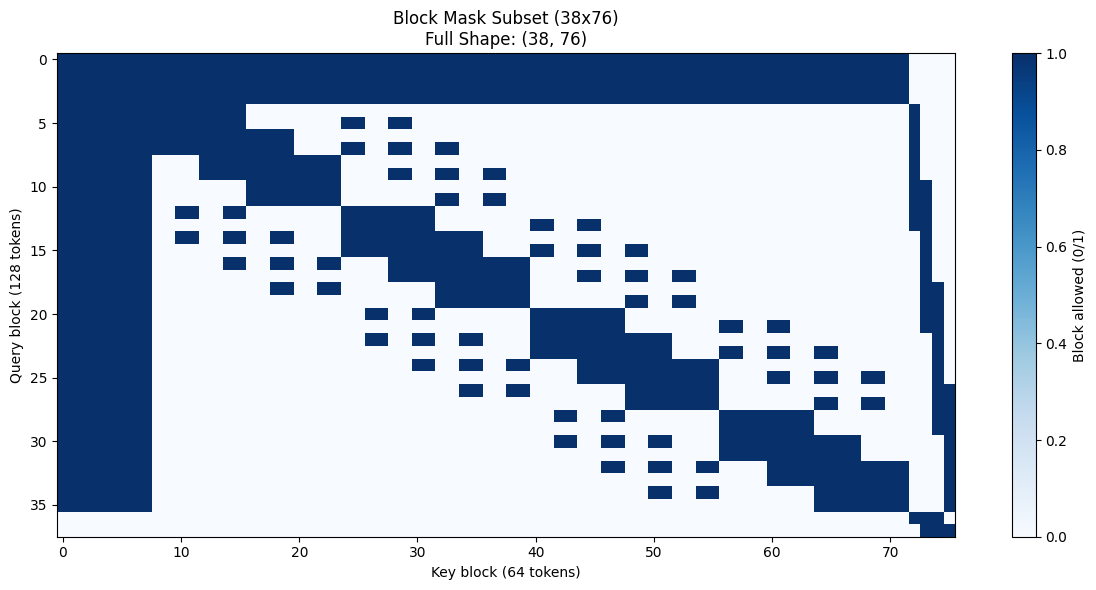

In [10]:
import matplotlib.pyplot as plt

# Visualize the (small) blocksparse mask directly
bm = block_mask  # (Q_blocks, K_blocks) bool

# Show a bottom-right subset (often the LR region sits near the end)
subset_q = min(300, bm.shape[0])
subset_k = min(600, bm.shape[1])

bm_subset = bm[-subset_q:, -subset_k:].to(torch.uint8).numpy()

plt.figure(figsize=(12, 6))
plt.imshow(bm_subset, cmap="Blues", aspect="auto", interpolation="nearest")
plt.colorbar(label="Block allowed (0/1)")
plt.title(f"Block Mask Subset ({subset_q}x{subset_k})\nFull Shape: {tuple(bm.shape)}")
plt.xlabel("Key block (64 tokens)")
plt.ylabel("Query block (128 tokens)")
plt.tight_layout()
plt.show()


Block mask shape: (38, 76) (Q_blocks, K_blocks)
Allowed blocks: 1034 / 2888 (35.803%)


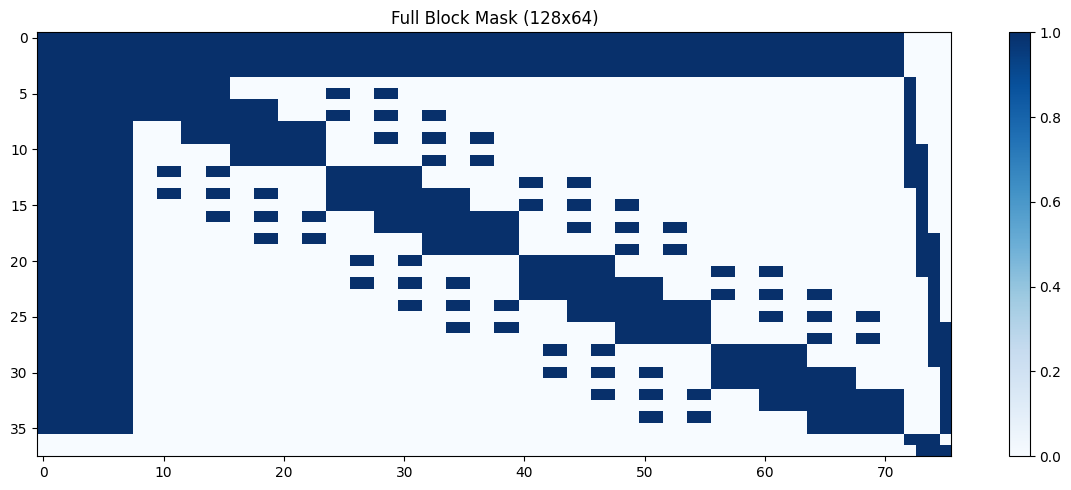

In [11]:
# The notebook now builds `block_mask` directly (so there is nothing to downsample from a dense NxN mask).
# If you need to validate against a small dense mask, do it only for small image sizes.

import matplotlib.pyplot as plt

print(f"Block mask shape: {tuple(block_mask.shape)} (Q_blocks, K_blocks)")
print(f"Allowed blocks: {int(block_mask.sum().item())} / {block_mask.numel()} ({100.0*block_mask.float().mean().item():.3f}%)")

plt.figure(figsize=(12, 5))
plt.imshow(block_mask.to(torch.uint8).numpy(), cmap="Blues", aspect="auto", interpolation="nearest")
plt.title("Full Block Mask (128x64)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [6]:
block_mask.shape

torch.Size([2180, 4360])

In [7]:
# Optional: if you ever need to “expand” block decisions back to token space,
# do it only for tiny toy sizes (dense NxN is not feasible at Scale-DiT resolutions).
#
# For Sage blocksparse runtime you should keep and use `block_mask` directly.


In [8]:
# (intentionally left blank)
# The blocksparse mask builder is defined earlier in the notebook (Cell 1).
